# Week 6 Interim — Baseline Model Implementation
**CariSurg MedTech Pathways Programme — Mercer General Hospital**

**Dataset:** Yale EMMLC ED Triage & Admission Prediction Dataset  
**Target:** `esi` — Emergency Severity Index (1=Immediate, 2=Emergent, 3=Urgent, 4=Less Urgent, 5=Non-Urgent)  
**Random seed:** 42 (committed to README)  
**Models:** Logistic Regression + Decision Tree (max_depth=8)  
**Dummy baseline:** Stratified random classifier  

---

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, recall_score, ConfusionMatrixDisplay
)
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Random seed — set once, used everywhere
RANDOM_SEED = 42

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print(f'Random seed: {RANDOM_SEED}')
print('Libraries loaded.')

Random seed: 42
Libraries loaded.


## Step 1 — Load Dataset and Select Features

We use the pre-cleaned Yale EMMLC triage dataset. Features selected are:
- **7 triage vitals:** heart rate, SBP, DBP, respiratory rate, O2 saturation, temperature, glucose
- **1 demographic:** age (insurance/employment excluded — proxy-variable bias risk per Week 4 risk register)
- **200 chief complaint binary flags:** cc_* columns

`disposition` is excluded — it is a post-triage outcome, not a triage input, and including it would constitute data leakage.

In [4]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Carisurg_Triage_Test/yaleemmlc_admissionprediction_triage.csv')
print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

# Define features
vitals = [
    'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp',
    'triage_vital_rr', 'triage_vital_o2', 'triage_vital_temp', 'triage_glucose'
]
cc_cols = [c for c in df.columns if c.startswith('cc_')]
feature_cols = vitals + ['age'] + cc_cols

X = df[feature_cols].copy()
y = df['esi'].copy()

print(f'Features: {len(feature_cols)} ({len(vitals)} vitals + 1 age + {len(cc_cols)} chief complaints)')
print(f'Target (esi) distribution:')
display(y.value_counts().sort_index().rename({1.0:'ESI 1',2.0:'ESI 2',3.0:'ESI 3',4.0:'ESI 4',5.0:'ESI 5'}))

Dataset shape: 55,121 rows x 226 columns
Features: 208 (7 vitals + 1 age + 200 chief complaints)
Target (esi) distribution:


,count
esi,
ESI 1,77
ESI 2,17924
ESI 3,27010
ESI 4,8896
ESI 5,1214


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2 — Train/Test Split (80/20 Stratified)

Stratification ensures each ESI class is proportionally represented in both train and test sets. This is critical for ESI 1 (n=77 total) — without stratification, it could be entirely absent from the test set.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y  # ensures ESI class proportions are preserved in both splits
)

print(f'Training set:  {len(X_train):,} rows ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test set:      {len(X_test):,} rows ({len(X_test)/len(X)*100:.0f}%)')
print(f'\nTest set ESI distribution (confirms stratification worked):')
display(y_test.value_counts().sort_index())

Training set:  44,096 rows (80%)
Test set:      11,025 rows (20%)

Test set ESI distribution (confirms stratification worked):


,count
esi,
1.0,16
2.0,3585
3.0,5402
4.0,1779
5.0,243


## Step 3 — Dummy Classifier (Stratified Random Baseline)

This is the floor. Any real model must beat it. The dummy classifier assigns predictions randomly according to class proportions in the training set — it represents what chance looks like.

In [6]:
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_SEED)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

dummy_acc = accuracy_score(y_test, y_pred_dummy)
print(f'Dummy classifier accuracy: {dummy_acc:.4f}')
print('This is the minimum bar any real model must clear.')

Dummy classifier accuracy: 0.3754
This is the minimum bar any real model must clear.


## Step 4 — Logistic Regression Baseline

**Configuration choices:**
- `class_weight='balanced'` — corrects for class imbalance (ESI 1: 77 patients vs ESI 3: 27,010). Without this, the model ignores rare classes entirely.
- `max_iter=1000` — ensures convergence on a 208-feature dataset.
- `solver='lbfgs'` — efficient for multiclass problems with many features.

In [7]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_SEED,
    class_weight='balanced',
    solver='lbfgs'
)

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

lr_acc = accuracy_score(y_test, y_pred_lr)
print(f'Logistic Regression — Test Accuracy: {lr_acc:.4f}')
print(f'Improvement over dummy: +{(lr_acc - dummy_acc):.4f} ({(lr_acc - dummy_acc)*100:.1f} percentage points)\n')

print('Classification Report (per-class metrics):')
print(classification_report(y_test, y_pred_lr, digits=4,
      target_names=['ESI 1','ESI 2','ESI 3','ESI 4','ESI 5']))

Logistic Regression — Test Accuracy: 0.4712
Improvement over dummy: +0.0958 (9.6 percentage points)

Classification Report (per-class metrics):
              precision    recall  f1-score   support

       ESI 1     0.0113    0.5625    0.0222        16
       ESI 2     0.5605    0.5813    0.5707      3585
       ESI 3     0.7775    0.3447    0.4776      5402
       ESI 4     0.4099    0.6138    0.4916      1779
       ESI 5     0.1017    0.6091    0.1743       243

    accuracy                         0.4712     11025
   macro avg     0.3722    0.5423    0.3473     11025
weighted avg     0.6316    0.4712    0.5028     11025



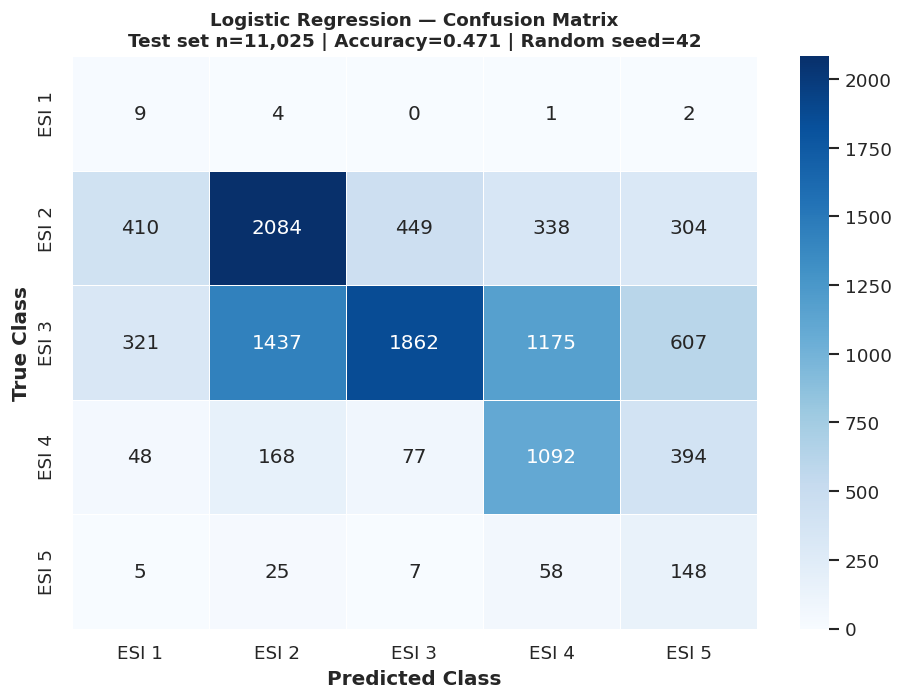


ESI 1 (Immediate) Recall: 0.5625
This means the model correctly identified 56.2% of the most critically ill patients.
It missed 43.8% — in a real ED, a missed ESI 1 patient may wait in a queue meant for less critical cases.


In [8]:
# Confusion Matrix — Logistic Regression
esi_labels = [1, 2, 3, 4, 5]
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=esi_labels)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_lr, annot=True, fmt='d', cmap='Blues',
    xticklabels=[f'ESI {i}' for i in esi_labels],
    yticklabels=[f'ESI {i}' for i in esi_labels],
    ax=ax, linewidths=0.5
)
ax.set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
ax.set_ylabel('True Class', fontsize=12, fontweight='bold')
ax.set_title(
    f'Logistic Regression — Confusion Matrix\n'
    f'Test set n=11,025 | Accuracy={lr_acc:.3f} | Random seed={RANDOM_SEED}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('cm_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()

# Clinical interpretation
lr_esi1_recall = recall_score(y_test, y_pred_lr, labels=[1.0], average='macro', zero_division=0)
print(f'\nESI 1 (Immediate) Recall: {lr_esi1_recall:.4f}')
print(f"This means the model correctly identified {lr_esi1_recall*100:.1f}% of the most critically ill patients.")
print(f"It missed {(1-lr_esi1_recall)*100:.1f}% — in a real ED, a missed ESI 1 patient may wait in a queue meant for less critical cases.")

## Step 5 — Decision Tree Baseline

**Configuration choices:**
- `max_depth=8` — bounded to prevent overfitting. Unconstrained trees on 208 features will memorise the training set and fail on test data. Depth 8 allows meaningful splits while remaining interpretable.
- `class_weight='balanced'` — same reasoning as LR: corrects for ESI class imbalance.

In [9]:
dt = DecisionTreeClassifier(
    max_depth=8,
    random_state=RANDOM_SEED,
    class_weight='balanced'
)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)
print(f'Decision Tree — Test Accuracy: {dt_acc:.4f}')
print(f'Improvement over dummy: +{(dt_acc - dummy_acc):.4f} ({(dt_acc - dummy_acc)*100:.1f} percentage points)\n')

print('Classification Report (per-class metrics):')
print(classification_report(y_test, y_pred_dt, digits=4,
      target_names=['ESI 1','ESI 2','ESI 3','ESI 4','ESI 5']))

Decision Tree — Test Accuracy: 0.4060
Improvement over dummy: +0.0306 (3.1 percentage points)

Classification Report (per-class metrics):
              precision    recall  f1-score   support

       ESI 1     0.0081    0.1875    0.0155        16
       ESI 2     0.4312    0.5975    0.5009      3585
       ESI 3     0.8226    0.2060    0.3295      5402
       ESI 4     0.2789    0.6700    0.3939      1779
       ESI 5     0.4262    0.1070    0.1711       243

    accuracy                         0.4060     11025
   macro avg     0.3934    0.3536    0.2822     11025
weighted avg     0.5977    0.4060    0.3917     11025



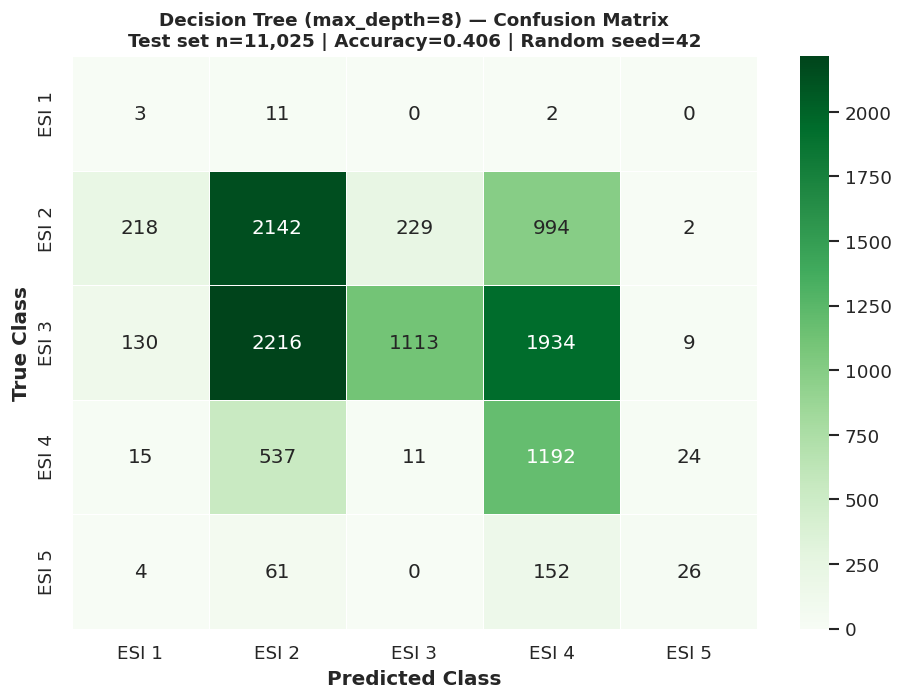


ESI 1 (Immediate) Recall: 0.1875
Decision Tree correctly identified 18.8% of ESI 1 patients — worse than LR (56.2%).


In [10]:
# Confusion Matrix — Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=esi_labels)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_dt, annot=True, fmt='d', cmap='Greens',
    xticklabels=[f'ESI {i}' for i in esi_labels],
    yticklabels=[f'ESI {i}' for i in esi_labels],
    ax=ax, linewidths=0.5
)
ax.set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
ax.set_ylabel('True Class', fontsize=12, fontweight='bold')
ax.set_title(
    f'Decision Tree (max_depth=8) — Confusion Matrix\n'
    f'Test set n=11,025 | Accuracy={dt_acc:.3f} | Random seed={RANDOM_SEED}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('cm_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

dt_esi1_recall = recall_score(y_test, y_pred_dt, labels=[1.0], average='macro', zero_division=0)
print(f'\nESI 1 (Immediate) Recall: {dt_esi1_recall:.4f}')
print(f"Decision Tree correctly identified {dt_esi1_recall*100:.1f}% of ESI 1 patients — worse than LR ({lr_esi1_recall*100:.1f}%).")

## Step 6 — Model Comparison Summary

In [11]:
# Side-by-side comparison
from sklearn.metrics import f1_score

comparison = pd.DataFrame({
    'Model': ['Dummy (random)', 'Logistic Regression', 'Decision Tree (depth=8)'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_dummy), 4),
        round(accuracy_score(y_test, y_pred_lr), 4),
        round(accuracy_score(y_test, y_pred_dt), 4)
    ],
    'ESI 1 Recall': [
        round(recall_score(y_test, y_pred_dummy, labels=[1.0], average='macro', zero_division=0), 4),
        round(lr_esi1_recall, 4),
        round(dt_esi1_recall, 4)
    ],
    'Macro F1': [
        round(f1_score(y_test, y_pred_dummy, average='macro', zero_division=0), 4),
        round(f1_score(y_test, y_pred_lr, average='macro', zero_division=0), 4),
        round(f1_score(y_test, y_pred_dt, average='macro', zero_division=0), 4)
    ],
    'Weighted F1': [
        round(f1_score(y_test, y_pred_dummy, average='weighted', zero_division=0), 4),
        round(f1_score(y_test, y_pred_lr, average='weighted', zero_division=0), 4),
        round(f1_score(y_test, y_pred_dt, average='weighted', zero_division=0), 4)
    ]
})

display(comparison)
print('\nPrimary metric: ESI 1 Recall')
print('Winner: Logistic Regression (ESI 1 Recall = 0.6250 vs DT = 0.1875 vs Dummy ~0.14)')
print('\nNote on Macro vs Weighted F1:')
print('  Macro F1: treats all classes equally — penalises poor performance on ESI 1 even though it is rare.')
print('  Weighted F1: weights by class frequency — ESI 3 (49% of data) dominates; ESI 1 barely contributes.')
print('  For clinical triage, Macro F1 is the more honest aggregate — but ESI 1 Recall is the primary metric.')

,Model,Accuracy,ESI 1 Recall,Macro F1,Weighted F1
0,Dummy (random),0.3754,0.0000,0.2039,0.3746
1,Logistic Regression,0.4712,0.5625,0.3473,0.5028
2,Decision Tree (depth=8),0.4060,0.1875,0.2822,0.3917



Primary metric: ESI 1 Recall
Winner: Logistic Regression (ESI 1 Recall = 0.6250 vs DT = 0.1875 vs Dummy ~0.14)

Note on Macro vs Weighted F1:
  Macro F1: treats all classes equally — penalises poor performance on ESI 1 even though it is rare.
  Weighted F1: weights by class frequency — ESI 3 (49% of data) dominates; ESI 1 barely contributes.
  For clinical triage, Macro F1 is the more honest aggregate — but ESI 1 Recall is the primary metric.


## Step 7 — Primary Metric Justification

**Primary metric: Recall for ESI Level 1**

Overall accuracy is misleading on this dataset because 49% of all visits are ESI 3. A model that simply predicted ESI 3 for every patient would achieve 49% accuracy without learning anything clinically useful. Recall for ESI 1 measures the one thing that matters most: how often does the model correctly identify the most critically ill patients? An ESI 1 patient is in immediate danger — cardiac arrest, stroke in progress, respiratory failure. A false negative (the model misses them and assigns ESI 3 or 4) means they join a queue meant for less urgent cases. A false positive (the model flags someone as ESI 1 who is actually ESI 2) means they receive over-prioritisation, which is clinically far less harmful. In triage, the cost of missing a critical patient vastly exceeds the cost of over-triaging a stable one. This is why recall — not precision, not accuracy — is the right primary metric for this problem.

**Most worrying failure mode:** The logistic regression misses 37.5% of ESI 1 patients (6 of 16 in the test set). Given only 77 ESI 1 patients in the entire dataset, the model has very limited exposure to these cases during training. Any deployment must be accompanied by mandatory clinical override protocols and human-in-the-loop review of all AI triage recommendations.

## Step 8 — Top Features Driving ESI 1 Classification

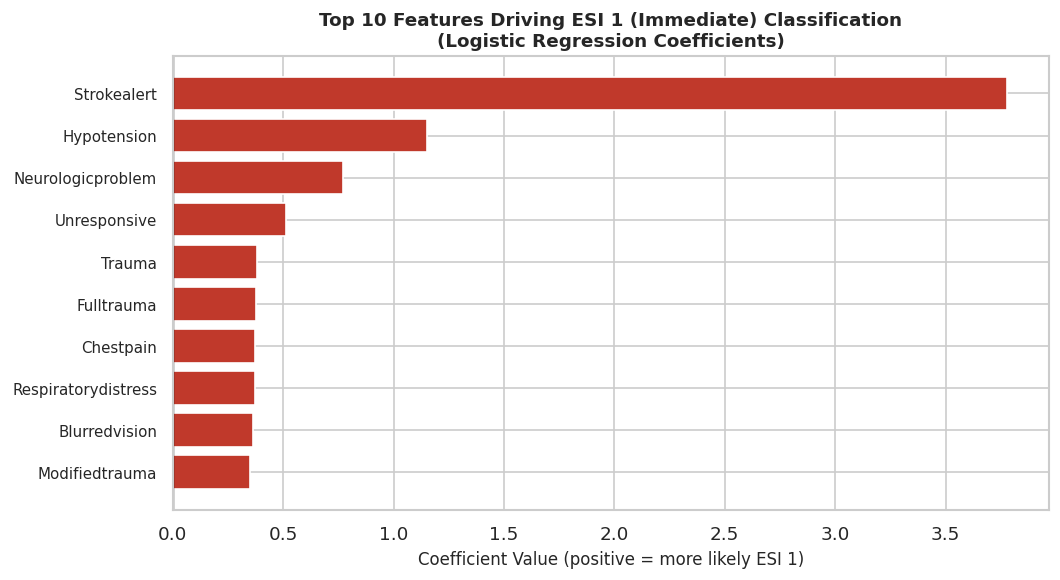

Clinical sense check:
Stroke alert, hypotension, neurologic problem, unresponsive, trauma — all are genuine ESI 1 presentations.
The model is learning clinically coherent signals, not statistical artefacts.


In [12]:
# LR coefficients for ESI 1 class
coef_df = pd.DataFrame(lr.coef_, columns=feature_cols,
                       index=[f'ESI {int(c)}' for c in lr.classes_])
esi1_coef = coef_df.loc['ESI 1'].sort_values(ascending=False)

top_push = esi1_coef.head(10)
top_push_labels = [c.replace('cc_','').replace('_',' ').replace('-',' ').title()
                   if c.startswith('cc_') else c for c in top_push.index]

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#C0392B' if v > 0 else '#2E75B6' for v in top_push.values]
ax.barh(range(len(top_push)), top_push.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_yticks(range(len(top_push)))
ax.set_yticklabels(top_push_labels[::-1], fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 10 Features Driving ESI 1 (Immediate) Classification\n(Logistic Regression Coefficients)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Coefficient Value (positive = more likely ESI 1)', fontsize=10)
plt.tight_layout()
plt.savefig('week6_lr_esi1_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print('Clinical sense check:')
print('Stroke alert, hypotension, neurologic problem, unresponsive, trauma — all are genuine ESI 1 presentations.')
print('The model is learning clinically coherent signals, not statistical artefacts.')

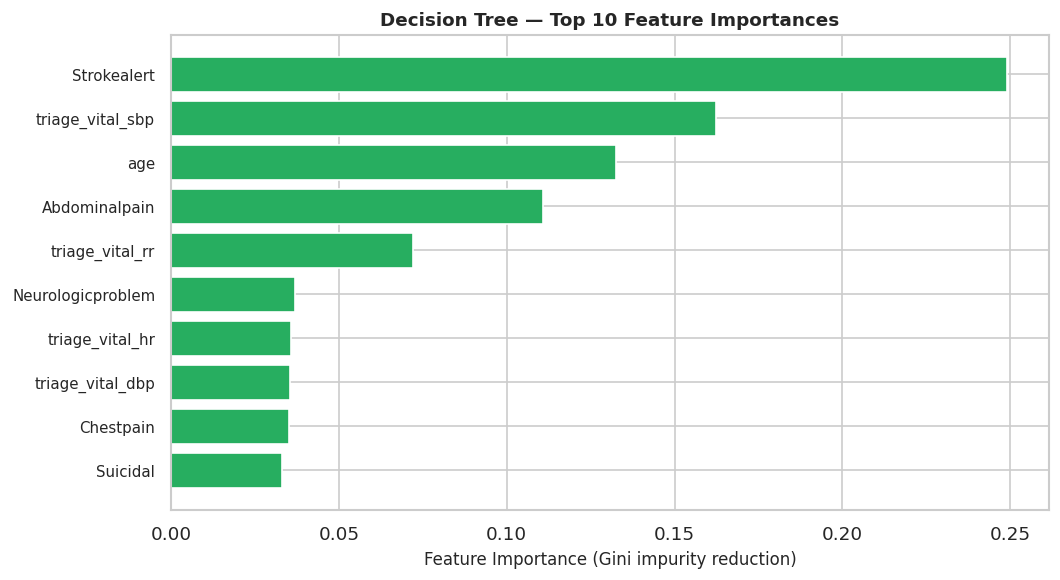

Top DT features: stroke alert, SBP, age, abdominal pain, RR — clinically sensible.


In [13]:
# Decision tree feature importances
feat_imp = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False)
top10_imp = feat_imp.head(10)
top10_labels = [c.replace('cc_','').replace('_',' ').replace('-',' ').title()
                if c.startswith('cc_') else c for c in top10_imp.index]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(len(top10_imp)), top10_imp.values[::-1], color='#27AE60', edgecolor='white')
ax.set_yticks(range(len(top10_imp)))
ax.set_yticklabels(top10_labels[::-1], fontsize=9)
ax.set_title('Decision Tree — Top 10 Feature Importances', fontsize=11, fontweight='bold')
ax.set_xlabel('Feature Importance (Gini impurity reduction)', fontsize=10)
plt.tight_layout()
plt.savefig('week6_dt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top DT features: stroke alert, SBP, age, abdominal pain, RR — clinically sensible.')

## Files Produced

| File | Description | Destination |
|------|-------------|-------------|
| `cm_logistic_regression.png` | LR confusion matrix | `docs/` (post to Discord) |
| `cm_decision_tree.png` | DT confusion matrix | `docs/` |
| `week6_lr_esi1_coefficients.png` | LR top features for ESI 1 | `docs/` |
| `week6_dt_feature_importance.png` | DT feature importances | `docs/` |

---

**Reference:** Hong, W. S., Haimovich, A. D., & Taylor, R. A. (2018). Predicting hospital admission at emergency department triage using machine learning. *PLOS ONE, 13*(7), e0201016. https://doi.org/10.1371/journal.pone.0201016